In [1]:
!pip install -q albumentations
!pip install -q timm

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [3]:
TRAIN_CSV = "/kaggle/input/datasets/mannyquin1/celeba-datasets/celeba_train.csv"
VAL_CSV = "/kaggle/input/datasets/mannyquin1/celeba-datasets/celeba_val.csv"
TEST_CSV = "/kaggle/input/datasets/mannyquin1/celeba-datasets/celeba_test.csv"

IMAGE_DIR = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"
IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 2

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(162079, 18)
(20260, 18)
(20260, 18)


(218, 178, 3)


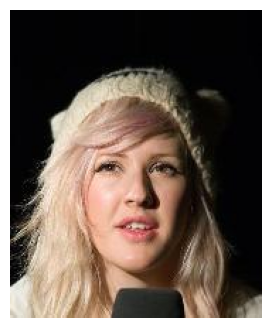

In [13]:
row = train_df.iloc[0]

img = cv2.imread(os.path.join(IMAGE_DIR, row["image_id"]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(img.shape)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.show()

In [5]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

In [6]:
class CelebADataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = os.path.join(
            self.image_dir,
            row["image_id"]
        )

        image = cv2.imread(img_path)

        if image is None:
            raise FileNotFoundError(
                f"Image not found: {img_path}"
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        if self.transform:
            image = self.transform(image=image)["image"]

        hair_color = torch.as_tensor(
            row["hair_color"],
            dtype=torch.long
        )

        texture = row["hair_texture"]

        # Unknown → ignore during training
        if texture == 2:
            texture = -1

        hair_texture = torch.as_tensor(
            texture,
            dtype=torch.long
        )

        hair_attributes = torch.as_tensor([
            row["bald"],
            row["bangs"],
            row["receding"]
        ], dtype=torch.float32)
        

        facial_hair = torch.as_tensor([
            row["mustache"],
            row["goatee"],
            row["sideburns"]
        ], dtype=torch.float32)


        accessories = torch.as_tensor([
            row["glasses"],
            row["hat"],
            row["earrings"]
        ], dtype=torch.float32)


        face_features = torch.as_tensor([
            row["oval_face"],
            row["high_cheekbones"],
            row["arched_eyebrows"],
            row["bushy_eyebrows"],
            row["big_nose"],
            row["big_lips"]
        ], dtype=torch.float32)

        return {
            "image_id": row["image_id"],

            "image": image,

            "hair_color": hair_color,

            "hair_texture": hair_texture,

            "hair_attributes": hair_attributes,

            "facial_hair": facial_hair,

            "accessories": accessories,

            "face_features": face_features

        }

In [7]:
train_dataset = CelebADataset(
    dataframe=train_df,
    image_dir=IMAGE_DIR,
    transform=train_transform
)

val_dataset = CelebADataset(
    dataframe=val_df,
    image_dir=IMAGE_DIR,
    transform=valid_transform
)

test_dataset = CelebADataset(
    dataframe=test_df,
    image_dir=IMAGE_DIR,
    transform=valid_transform
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

162079
20260
20260


In [8]:
sample = train_dataset[0]

print(sample.keys())

for key, value in sample.items():

    if isinstance(value, torch.Tensor):

        print(
            key,
            value.shape,
            value.dtype
        )

dict_keys(['image_id', 'image', 'hair_color', 'hair_texture', 'hair_attributes', 'facial_hair', 'accessories', 'face_features'])
image torch.Size([3, 224, 224]) torch.float32
hair_color torch.Size([]) torch.int64
hair_texture torch.Size([]) torch.int64
hair_attributes torch.Size([3]) torch.float32
facial_hair torch.Size([3]) torch.float32
accessories torch.Size([3]) torch.float32
face_features torch.Size([6]) torch.float32


In [9]:
print(train_dataset)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [11]:
batch = next(iter(train_loader))

for key, value in batch.items():

    if isinstance(value, torch.Tensor):
        print(key, value.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


image torch.Size([32, 3, 224, 224])
hair_color torch.Size([32])
hair_texture torch.Size([32])
hair_attributes torch.Size([32, 3])
facial_hair torch.Size([32, 3])
accessories torch.Size([32, 3])
face_features torch.Size([32, 6])


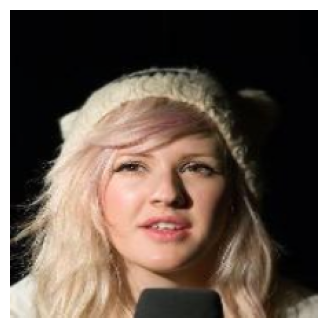

In [14]:
transformed = train_transform(image=img)["image"]

img2 = transformed.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img2 = img2 * std + mean
img2 = np.clip(img2, 0, 1)

plt.figure(figsize=(4,4))
plt.imshow(img2)
plt.axis("off")
plt.show()

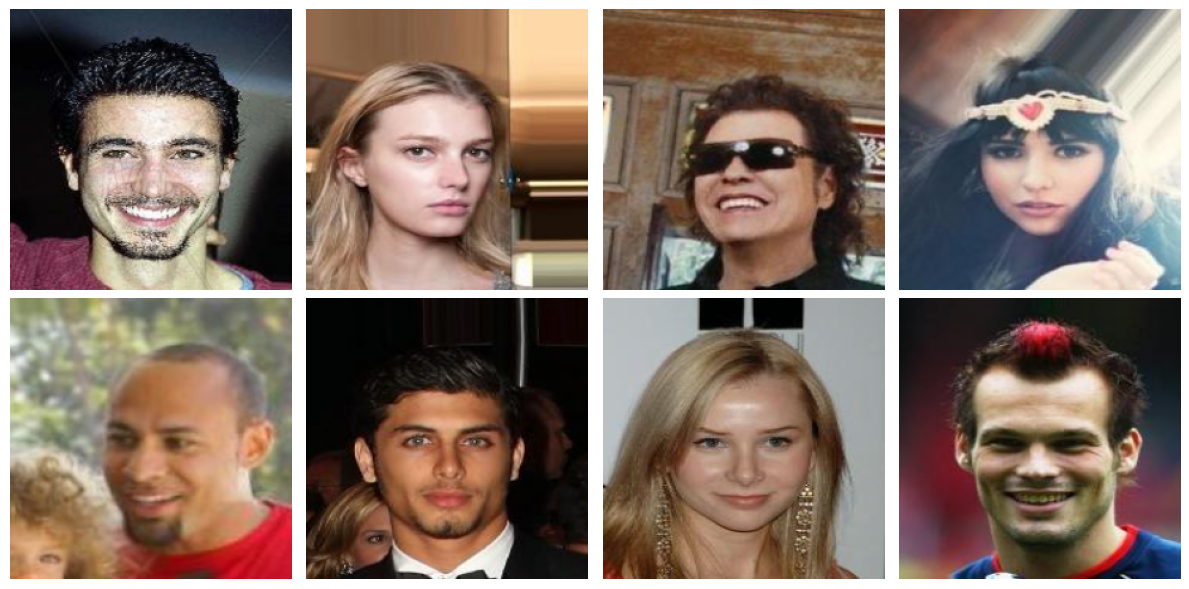

In [12]:
import matplotlib.pyplot as plt

batch = next(iter(train_loader))

images = batch["image"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1, 2, 0).numpy()

    # Undo ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img * std + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()